In [1]:
# --- Carga del dataset principal desde data_clean3.csv ---
# Comentarios: este bloque asegura que el notebook use siempre el CSV local
import pandas as pd
from pathlib import Path
from IPython.display import display

# Aseguramos la ruta relativa al archivo CSV local
data_path = Path("data_clean3.csv")
print("Buscando archivo en:", data_path.resolve())
if not data_path.exists():
    raise FileNotFoundError(f"No se encuentra {data_path} en el directorio de trabajo.")

# Leer CSV
df = pd.read_csv(data_path)
print("Columnas del dataset:", df.columns.tolist())
print("Filas/Columnas:", df.shape)
display(df.head())

# Crear una agregación por ciudad usando las columnas reales del CSV
target_cols = {"location_name", "latitude", "longitude", "temperature_celsius"}
if target_cols.issubset(df.columns):
    city_agg = df.groupby(["location_name", "latitude", "longitude"], as_index=False)["temperature_celsius"].mean()
    city_agg = city_agg.rename(columns={"temperature_celsius": "temp", "latitude": "lat", "longitude": "lon"})
    print("city_agg creado (temperatura media por ciudad). Filas:", len(city_agg))
    display(city_agg.head())
else:
    print("No se encontraron las columnas esperadas:", target_cols - set(df.columns))
    city_agg = df.copy()
    print("Se asigna `city_agg = df` como fallback.")

Buscando archivo en: C:\Users\janes\OneDrive\Escriptori\PART PMAAD GRÀFICS\data_clean3.csv
Columnas del dataset: ['location_name', 'latitude', 'longitude', 'last_updated', 'temperature_celsius', 'condition_text', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'humidity', 'cloud', 'uv_index', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM10', 'air_quality_us.epa.index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_illumination', 'rain', 'good_visibility', 'has_moonrise', 'has_moonset']
Filas/Columnas: (16790, 28)


,location_name,latitude,longitude,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,...,air_quality_us.epa.index,sunrise,sunset,moonrise,moonset,moon_illumination,rain,good_visibility,has_moonrise,has_moonset
0,Tirana,41.33,19.82,2024-05-16 10:45,19.0,Partly cloudy,11.2,320,N,1012,...,1,5.350000,19.900000,12.966667,2.233333,55,1,1,1,1
1,Vienna,48.20,16.37,2024-05-16 10:45,16.0,Partly cloudy,20.2,110,E,1013,...,1,5.233333,20.483333,13.000000,2.700000,55,0,1,1,1
2,Brussels,50.83,4.33,2024-05-16 10:45,15.0,Partly cloudy,6.1,240,W,1003,...,1,5.866667,21.466667,13.750000,3.633333,55,1,1,1,1
3,Sarajevo,43.85,18.38,2024-05-16 10:45,19.0,Partly cloudy,3.6,194,S,1012,...,1,5.333333,20.116667,13.000000,2.400000,55,0,1,1,1
4,Zagreb,45.80,16.00,2024-05-16 10:45,16.0,Partly cloudy,15.1,70,E,1012,...,1,5.383333,20.366667,13.100000,2.633333,55,0,1,1,1


city_agg creado (temperatura media por ciudad). Filas: 51


,location_name,lat,lon,temp
0,Amsterdam,52.3700,4.8900,19.794928
1,Amsterdam,52.3740,4.8897,10.793504
2,Belgrade,44.8000,20.4700,28.821739
3,Belgrade,44.8040,20.4651,12.392717
4,Berlin,52.5167,13.4000,9.319094


🗺️ Univariante Geoespacial
Gráfico 1 — Mapa de burbujas: Temperatura media por ciudad

  location_name  latitude  longitude      last_updated  temperature_celsius  \
0        Tirana     41.33      19.82  2024-05-16 10:45                 19.0   
1        Vienna     48.20      16.37  2024-05-16 10:45                 16.0   
2      Brussels     50.83       4.33  2024-05-16 10:45                 15.0   
3      Sarajevo     43.85      18.38  2024-05-16 10:45                 19.0   
4        Zagreb     45.80      16.00  2024-05-16 10:45                 16.0   

  condition_text  wind_kph  wind_degree wind_direction  pressure_mb  ...  \
0  Partly cloudy      11.2          320              N         1012  ...   
1  Partly cloudy      20.2          110              E         1013  ...   
2  Partly cloudy       6.1          240              W         1003  ...   
3  Partly cloudy       3.6          194              S         1012  ...   
4  Partly cloudy      15.1           70              E         1012  ...   

   air_quality_us.epa.index   sunrise     sunset   moonrise   moonse

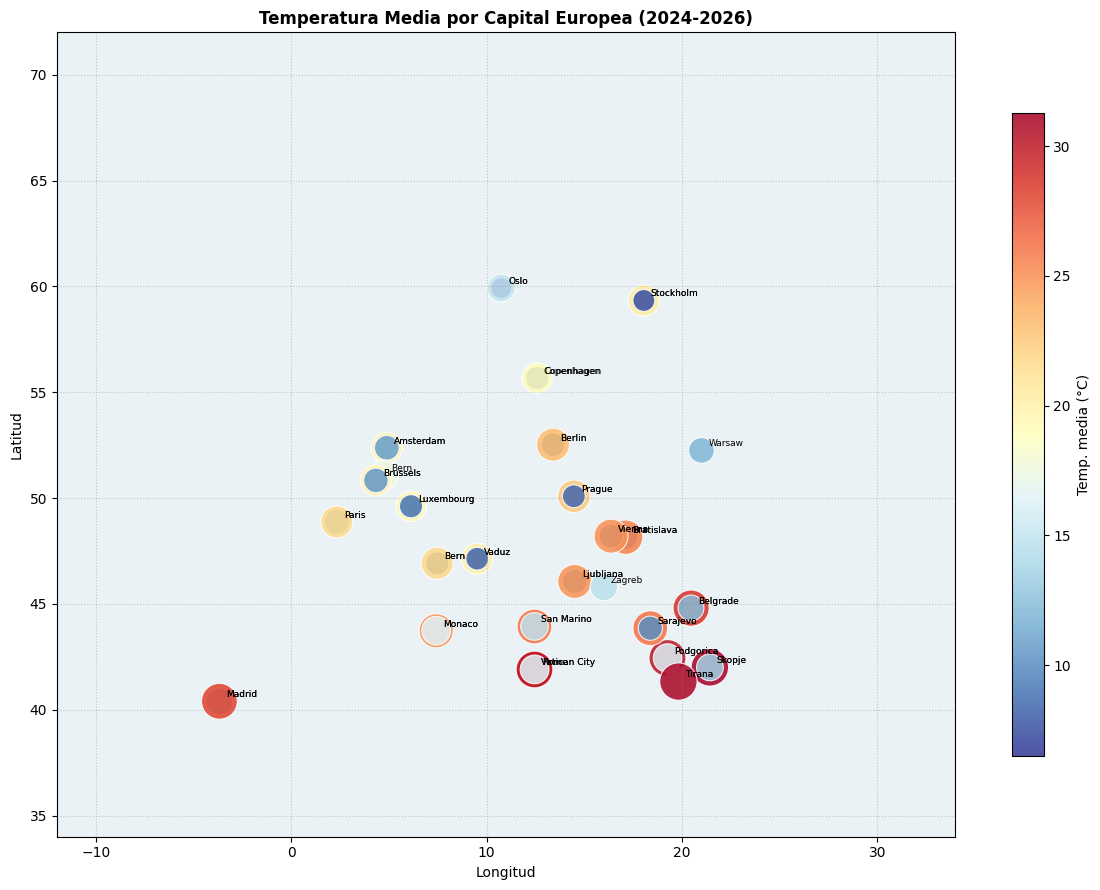

<Figure size 640x480 with 0 Axes>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

# ── Leer tu CSV local ─────────────────────────────────────
data_path = Path("data_clean3.csv")
df = pd.read_csv(data_path)
print(df.head())
print(df.columns.tolist())

# ── Agregar por ciudad (ajusta 'location_name', 'latitude', 'longitude', 'temperature_celsius') ──
city_agg = df.groupby(['location_name', 'latitude', 'longitude'], as_index=False)['temperature_celsius'].mean()
city_agg = city_agg.rename(columns={'temperature_celsius': 'temp', 'latitude': 'lat', 'longitude': 'lon'})

# ── Dibujar el mapa de burbujas en coordenadas europeas ───
fig, ax = plt.subplots(figsize=(12, 9))
ax.set_facecolor('#eaf2f5')
ax.set_xlim(-12, 34)
ax.set_ylim(34, 72)
ax.grid(True, linestyle=':', color='gray', alpha=0.4)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')

norm = mcolors.Normalize(vmin=city_agg['temp'].min(), vmax=city_agg['temp'].max())
sc = ax.scatter(city_agg['lon'], city_agg['lat'],
                c=city_agg['temp'], cmap='RdYlBu_r', norm=norm,
                s=city_agg['temp'].apply(lambda x: max(80, (x+5)*20)),
                alpha=0.85, edgecolor='white', linewidth=0.8)
plt.colorbar(sc, ax=ax, label='Temp. media (°C)', shrink=0.8)
ax.set_title('Temperatura Media por Capital Europea (2024-2026)', fontweight='bold')
for _, row in city_agg.iterrows():
    ax.annotate(row['location_name'], (row['lon'], row['lat']),
                xytext=(5, 3), textcoords='offset points', fontsize=6.5)
plt.tight_layout()
plt.show()
plt.savefig('map_temperatura.png', dpi=150)

Conclusiones:

Hay un claro gradiente norte-sur: Tirana (20.1°C), Roma (19.3°C) vs Oslo (8.3°C), Estocolmo (10.1°C)

Las capitales mediterráneas superan en ~10°C a las escandinavas

Vaduz y Berna son las más frías de Europa Central por efecto altitudinal

# 1 COCHES ELECTRICOS


## 1.1 pm10 por ciudad europea

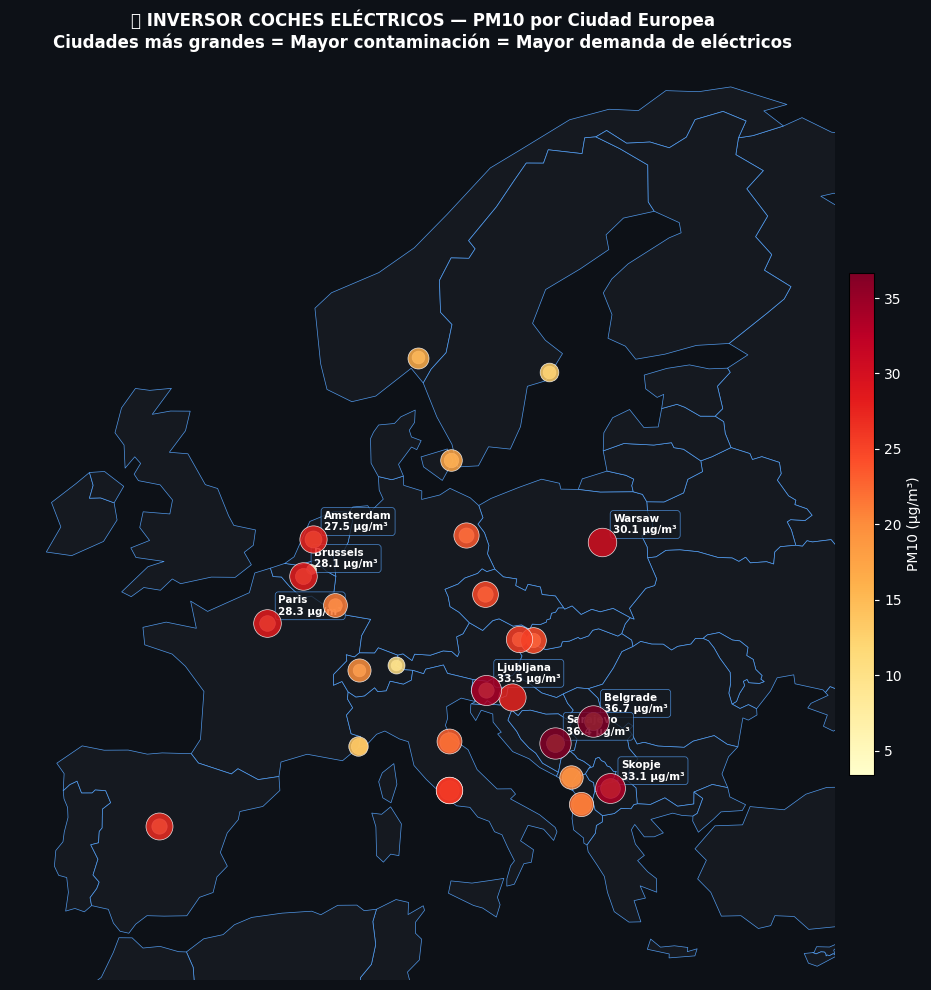

In [3]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import requests, zipfile, io
import warnings
warnings.filterwarnings('ignore')

# ── Cargar datos ──
df = pd.read_csv('data_clean3.csv')
city_agg = df.groupby(['location_name','latitude','longitude'], as_index=False).agg(
    PM10=('air_quality_PM10','mean'),
    NO2=('air_quality_Nitrogen_dioxide','mean'),
    EPA=('air_quality_us.epa.index','mean')
).dropna()

# ── Mapa Europa ──
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("/tmp/ne_countries")
world = gpd.read_file("/tmp/ne_countries/ne_110m_admin_0_countries.shp")
europe = world.cx[-15:35, 34:72]

BG, SURFACE, BORDER = '#0d1117', '#161b22', '#30363d'

fig, ax = plt.subplots(figsize=(14, 10), facecolor=BG)
ax.set_facecolor(BG)
europe.plot(ax=ax, color=SURFACE, edgecolor='#58a6ff', linewidth=0.5, alpha=0.9)
ax.set_xlim(-12, 34); ax.set_ylim(34, 72)

norm = mcolors.Normalize(vmin=city_agg['PM10'].min(), vmax=city_agg['PM10'].max())
cmap = cm.get_cmap('YlOrRd')

for _, row in city_agg.sort_values('PM10').iterrows():
    c = cmap(norm(row['PM10']))
    s = max(50, row['PM10'] * 14)
    ax.scatter(row['longitude'], row['latitude'], s=s, c=[c],
               alpha=0.85, edgecolor='white', linewidth=0.5, zorder=5)

# Etiquetar top 8
for _, row in city_agg.nlargest(8, 'PM10').iterrows():
    ax.annotate(f"{row['location_name']}\n{row['PM10']:.1f} µg/m³",
                (row['longitude'], row['latitude']),
                xytext=(8, 6), textcoords='offset points',
                color='white', fontsize=7.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc=SURFACE, alpha=0.8, ec='#58a6ff', lw=0.5))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, shrink=0.55, pad=0.01)
cbar.set_label('PM10 (µg/m³)', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

ax.set_title('🚗 INVERSOR COCHES ELÉCTRICOS — PM10 por Ciudad Europea\n'
             'Ciudades más grandes = Mayor contaminación = Mayor demanda de eléctricos',
             color='white', fontsize=12, fontweight='bold', pad=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('grafico1_PM10_mapa.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## 1.2 pm10 por ciudad europea

In [4]:
ib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import requests, zipfile, io
import warnings
warnings.filterwarnings('ignore')

# ── Cargar datos ──
df = pd.read_csv('data_clean3.csv')
city_agg = df.groupby(['location_name','latitude','longitude'], as_index=False).agg(
    PM10=('air_quality_PM10','mean'),
    NO2=('air_quality_Nitrogen_dioxide','mean'),
    EPA=('air_quality_us.epa.index','mean')
).dropna()

# ── Mapa Europa ──
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("/tmp/ne_countries")
world = gpd.read_file("/tmp/ne_countries/ne_110m_admin_0_countries.shp")
europe = world.cx[-15:35, 34:72]

BG, SURFACE, BORDER = '#0d1117', '#161b22', '#30363d'

fig, ax = plt.subplots(figsize=(14, 10), facecolor=BG)
ax.set_facecolor(BG)
europe.plot(ax=ax, color=SURFACE, edgecolor='#58a6ff', linewidth=0.5, alpha=0.9)
ax.set_xlim(-12, 34); ax.set_ylim(34, 72)

norm = mcolors.Normalize(vmin=city_agg['PM10'].min(), vmax=city_agg['PM10'].max())
cmap = cm.get_cmap('YlOrRd')

for _, row in city_agg.sort_values('PM10').iterrows():
    c = cmap(norm(row['PM10']))
    s = max(50, row['PM10'] * 14)
    ax.scatter(row['longitude'], row['latitude'], s=s, c=[c],
               alpha=0.85, edgecolor='white', linewidth=0.5, zorder=5)

# Etiquetar top 8
for _, row in city_agg.nlargest(8, 'PM10').iterrows():
    ax.annotate(f"{row['location_name']}\n{row['PM10']:.1f} µg/m³",
                (row['longitude'], row['latitude']),
                xytext=(8, 6), textcoords='offset points',
                color='white', fontsize=7.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc=SURFACE, alpha=0.8, ec='#58a6ff', lw=0.5))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = plt.colorbar(sm, ax=ax, shrink=0.55, pad=0.01)
cbar.set_label('PM10 (µg/m³)', color='white', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='white', labelcolor='white')

ax.set_title('🚗 INVERSOR COCHES ELÉCTRICOS — PM10 por Ciudad Europea\n'
             'Ciudades más grandes = Mayor contaminación = Mayor demanda de eléctricos',
             color='white', fontsize=12, fontweight='bold', pad=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('grafico1_PM10_mapa.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

SyntaxError: invalid syntax (3215561707.py, line 1)

📌 Conclusión: Belgrade (36.7 µg/m³), Sarajevo (36.4 µg/m³) y Ljubljana (33.5 µg/m³) son los mercados más prioritarios para abrir concesionarios o puntos de carga de vehículos eléctricos. Los Balcanes presentan la mayor concentración de PM10 de Europa, indicando alta dependencia de vehículos de combustión y calefacción contaminante. Son mercados con alta necesidad y baja competencia eléctrica actual.

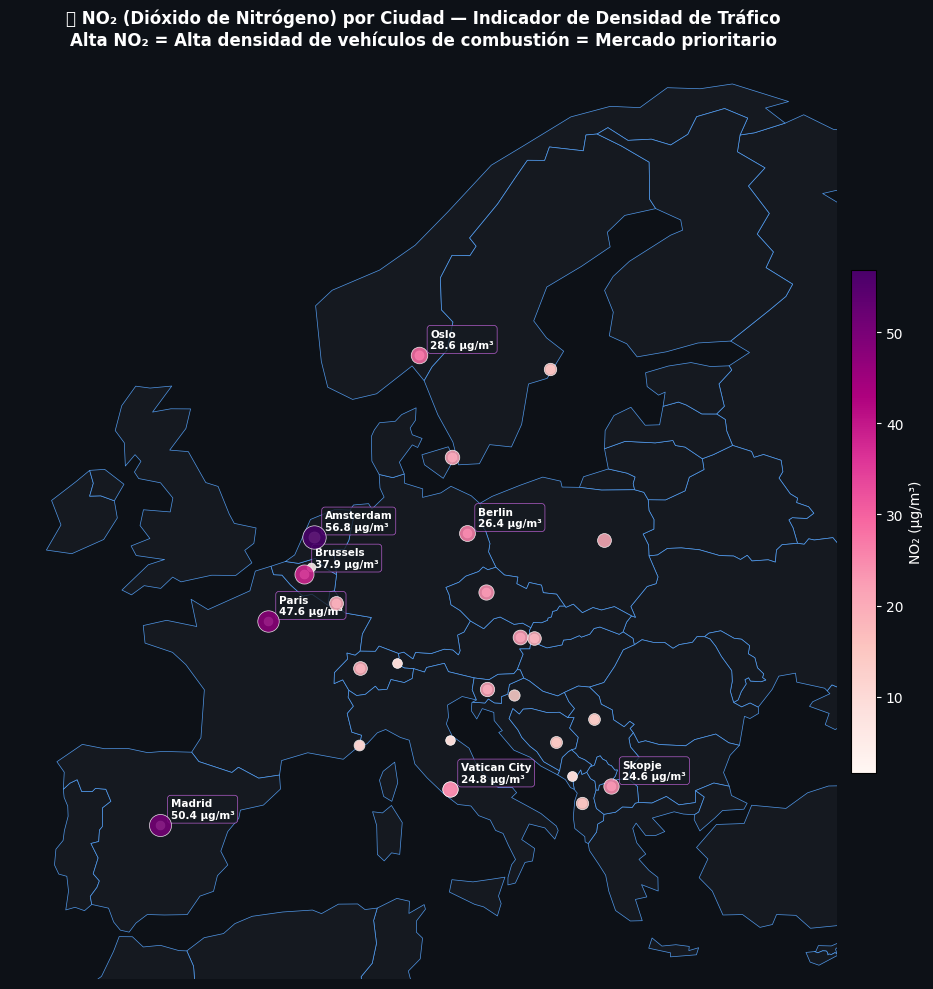

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10), facecolor=BG)
ax.set_facecolor(BG)
europe.plot(ax=ax, color=SURFACE, edgecolor='#58a6ff', linewidth=0.5, alpha=0.9)
ax.set_xlim(-12, 34); ax.set_ylim(34, 72)

norm2 = mcolors.Normalize(vmin=city_agg['NO2'].min(), vmax=city_agg['NO2'].max())
cmap2 = cm.get_cmap('RdPu')

for _, row in city_agg.sort_values('NO2').iterrows():
    c = cmap2(norm2(row['NO2']))
    s = max(40, row['NO2'] * 5)
    ax.scatter(row['longitude'], row['latitude'], s=s, c=[c],
               alpha=0.88, edgecolor='white', linewidth=0.5, zorder=5)

for _, row in city_agg.nlargest(8, 'NO2').iterrows():
    ax.annotate(f"{row['location_name']}\n{row['NO2']:.1f} µg/m³",
                (row['longitude'], row['latitude']),
                xytext=(8, 5), textcoords='offset points',
                color='white', fontsize=7.5, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc=SURFACE, alpha=0.8, ec='#da6ef5', lw=0.5))

sm2 = cm.ScalarMappable(cmap=cmap2, norm=norm2)
cbar2 = plt.colorbar(sm2, ax=ax, shrink=0.55, pad=0.01)
cbar2.set_label('NO₂ (µg/m³)', color='white', fontsize=10)
cbar2.ax.yaxis.set_tick_params(color='white', labelcolor='white')

ax.set_title('🏭 NO₂ (Dióxido de Nitrógeno) por Ciudad — Indicador de Densidad de Tráfico\n'
             'Alta NO₂ = Alta densidad de vehículos de combustión = Mercado prioritario',
             color='white', fontsize=12, fontweight='bold', pad=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('grafico2_NO2_mapa.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

📌 Conclusión: Amsterdam (56.8 µg/m³), Paris (47.6 µg/m³) y Madrid (50.4 µg/m³) tienen la mayor concentración de NO₂, directamente ligada al tráfico de combustión. A diferencia del PM10 (que incluye calefacción e industria), el NO₂ es el indicador más específico de tráfico rodado. Estas ciudades ya tienen o están cerca de implementar Zonas de Bajas Emisiones (ZBE), lo que convierte la demanda de eléctricos en urgente y normativa.

## Índice EPA Top20

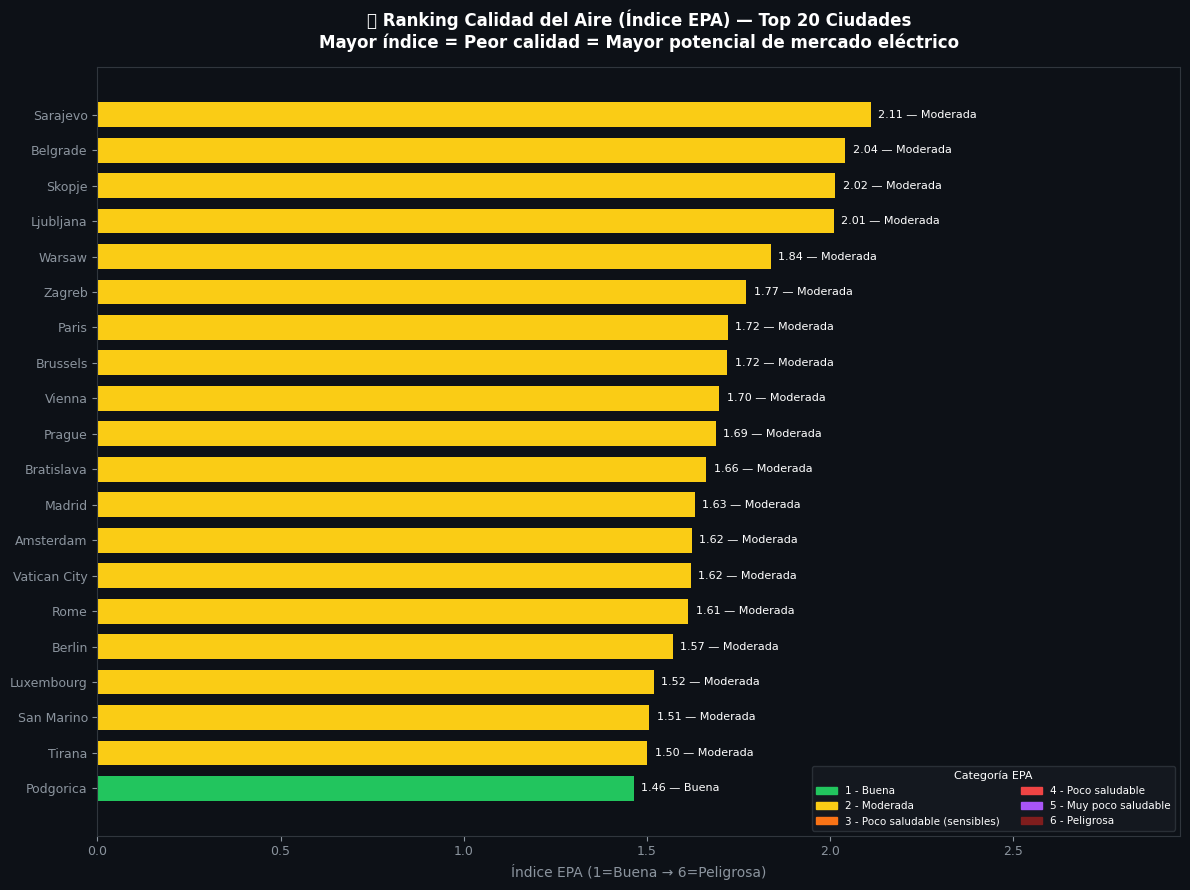

In [ ]:
import matplotlib.patches as mpatches

epa_labels = {1:'Buena', 2:'Moderada', 3:'Poco saludable (sensibles)',
              4:'Poco saludable', 5:'Muy poco saludable', 6:'Peligrosa'}
epa_colors = {1:'#22c55e', 2:'#facc15', 3:'#f97316',
              4:'#ef4444', 5:'#a855f7', 6:'#7f1d1d'}

top20 = city_agg.nlargest(20, 'EPA').sort_values('EPA')
colors_bar = [epa_colors.get(int(round(v)), '#ef4444') for v in top20['EPA']]

fig, ax = plt.subplots(figsize=(12, 9), facecolor=BG)
ax.set_facecolor(BG)
bars = ax.barh(top20['location_name'], top20['EPA'],
               color=colors_bar, edgecolor='none', height=0.7)

for bar, val in zip(bars, top20['EPA']):
    label = epa_labels.get(int(round(val)), '')
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f} — {label}', va='center', color='white', fontsize=8)

ax.set_xlabel('Índice EPA (1=Buena → 6=Peligrosa)', color='#8b949e', fontsize=10)
ax.set_title('📊 Ranking Calidad del Aire (Índice EPA) — Top 20 Ciudades\n'
             'Mayor índice = Peor calidad = Mayor potencial de mercado eléctrico',
             color='white', fontsize=12, fontweight='bold', pad=14)
ax.tick_params(colors='#8b949e', labelsize=9)
ax.set_xlim(0, top20['EPA'].max() * 1.4)
for sp in ax.spines.values(): sp.set_color(BORDER)

patches = [mpatches.Patch(color=epa_colors[k], label=f'{k} - {v}')
           for k, v in epa_labels.items()]
leg = ax.legend(handles=patches, fontsize=7.5, facecolor=SURFACE, labelcolor='white',
                edgecolor=BORDER, loc='lower right', title='Categoría EPA',
                title_fontsize=8, ncol=2)
leg.get_title().set_color('white')

plt.tight_layout()
plt.savefig('grafico3_EPA_ranking.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

📌 Conclusión: La mayoría de las capitales europeas se encuentran en categoría EPA 2 (Moderada) o 3 (Poco saludable para sensibles), con ciudades como Vatican City/Roma y Sarajevo rozando el 3. Ninguna ciudad está en categoría "Buena" de forma consistente, lo que indica que toda Europa es un mercado potencial para el vehículo eléctrico, pero los Balcanes y Europa del Este ofrecen el mayor margen de mejora y urgencia regulatoria.

## 1.4. PM10 y NO₂ por tiempo

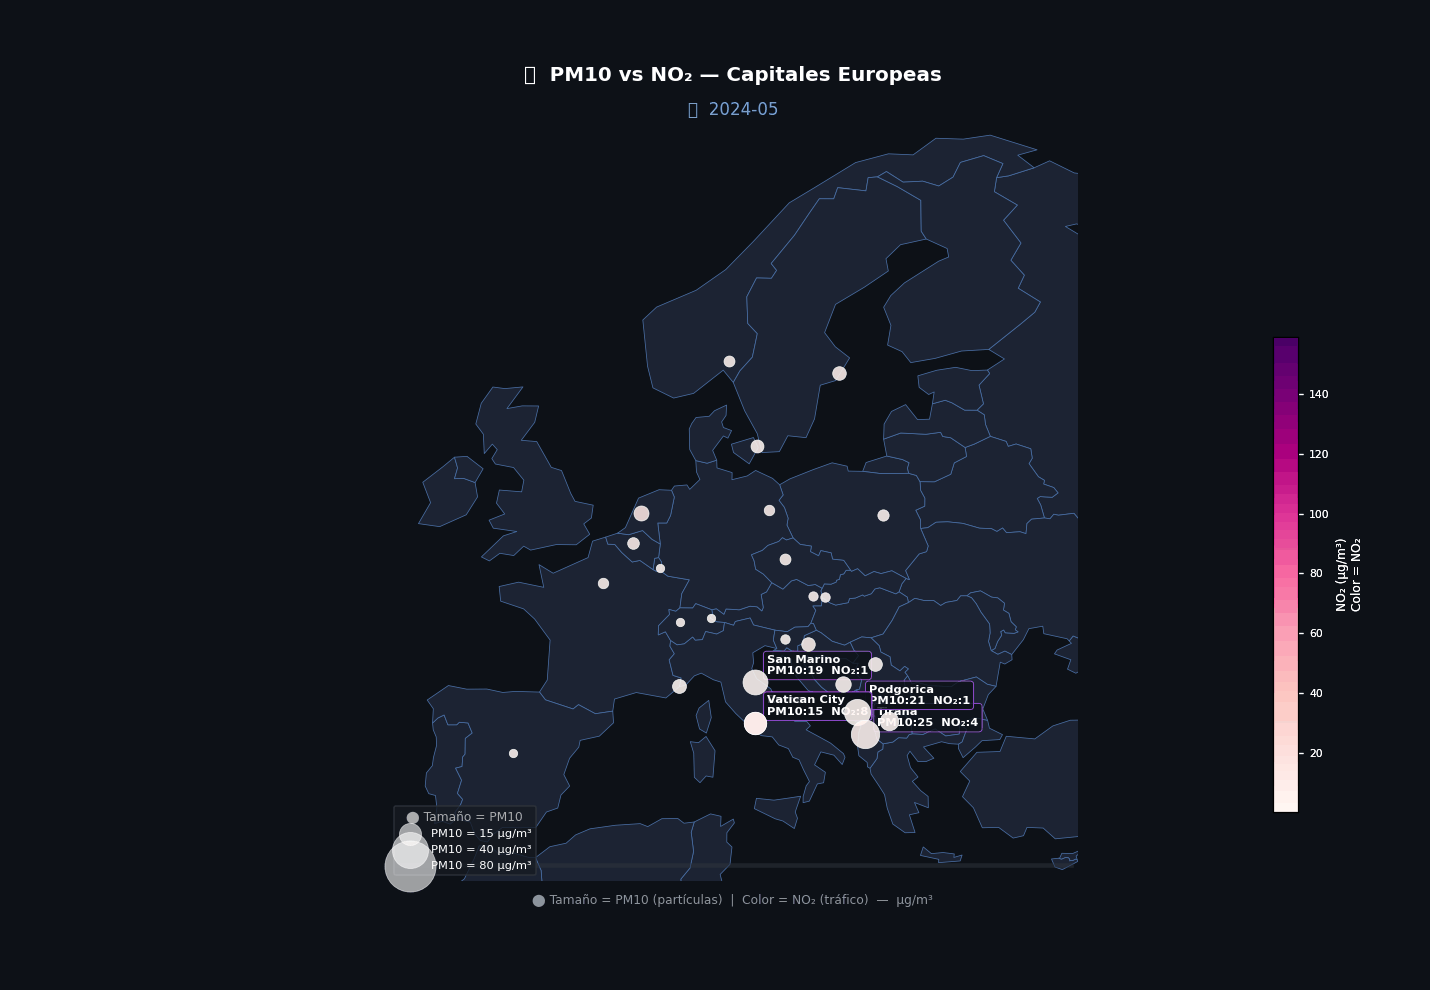

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation, PillowWriter
import requests, zipfile, io
import warnings
warnings.filterwarnings('ignore')

# ── Cargar datos ──
df = pd.read_csv('data_clean3.csv')
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['month_str'] = df['last_updated'].dt.strftime('%Y-%m')
months = sorted(df['month_str'].unique())

# ── Mapa Europa ──
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("/tmp/ne_countries")
world = gpd.read_file("/tmp/ne_countries/ne_110m_admin_0_countries.shp")
europe = world.cx[-15:35, 34:72]

# ── Rangos globales (escala fija en todos los frames) ──
norm_no2 = mcolors.Normalize(vmin=df['air_quality_Nitrogen_dioxide'].min(),
                              vmax=df['air_quality_Nitrogen_dioxide'].max())
cmap_no2 = cm.get_cmap('RdPu')   # claro = poco NO2, oscuro/morado = mucho NO2

# ── Precomputar por mes ──
monthly_data = {}
for m in months:
    monthly_data[m] = df[df['month_str'] == m].groupby(
        ['location_name','latitude','longitude'], as_index=False).agg(
        PM10=('air_quality_PM10','mean'),
        NO2=('air_quality_Nitrogen_dioxide','mean')
    ).dropna()

BG = '#0d1117'
fig, ax = plt.subplots(figsize=(13, 9), facecolor=BG)

def update(frame_idx):
    ax.clear()
    ax.set_facecolor(BG)
    month = months[frame_idx]
    europe.plot(ax=ax, color='#1c2333', edgecolor='#4a6fa5', linewidth=0.5)
    ax.set_xlim(-12, 34); ax.set_ylim(34, 72)
    ax.axis('off')

    md = monthly_data[month]
    for _, row in md.sort_values('PM10').iterrows():
        size  = max(30, row['PM10'] * 14)         # TAMAÑO = PM10
        color = cmap_no2(norm_no2(row['NO2']))    # COLOR  = NO2
        ax.scatter(row['longitude'], row['latitude'], s=size, c=[color],
                   alpha=0.88, edgecolor='white', linewidth=0.5, zorder=5)

    # Top 5 etiquetados
    for _, row in md.nlargest(5, 'PM10').iterrows():
        ax.annotate(f"{row['location_name']}\nPM10:{row['PM10']:.0f}  NO₂:{row['NO2']:.0f}",
                    (row['longitude'], row['latitude']),
                    xytext=(8, 5), textcoords='offset points',
                    color='white', fontsize=7.5, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', fc='#0d1117',
                              alpha=0.82, ec='#a855f7', lw=0.6))

    ax.text(0.5, 1.05, '🚗  PM10 vs NO₂ — Capitales Europeas',
            transform=ax.transAxes, ha='center', color='white',
            fontsize=13, fontweight='bold')
    ax.text(0.5, 1.005, f'📅  {month}',
            transform=ax.transAxes, ha='center', color='#58a6ff', fontsize=11)

    # Barra de progreso
    progress = frame_idx / max(len(months) - 1, 1)
    ax.axhline(y=34.8, xmin=0.01, xmax=0.99, color='#30363d', lw=3, alpha=0.5)
    ax.axhline(y=34.8, xmin=0.01, xmax=0.01 + 0.98*progress,
               color='#58a6ff', lw=3, alpha=0.75)

    # Leyenda tamaño PM10
    for val, lbl in [(15,'15'), (40,'40'), (80,'80')]:
        ax.scatter([], [], s=val*14, c='white', alpha=0.6,
                   edgecolor='white', lw=0.5, label=f'PM10 = {lbl} µg/m³')
    leg = ax.legend(title='⬤ Tamaño = PM10', title_fontsize=8, fontsize=7.5,
                    facecolor='#161b22', labelcolor='white',
                    edgecolor='#30363d', loc='lower left')
    leg.get_title().set_color('#aaaaaa')

    # Colorbar NO2
    sm = cm.ScalarMappable(cmap=cmap_no2, norm=norm_no2)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.89, 0.18, 0.018, 0.48])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label('NO₂ (µg/m³)\nColor = NO₂', color='white', fontsize=8)
    cb.ax.yaxis.set_tick_params(color='white', labelcolor='white', labelsize=7)

    ax.text(0.5, -0.03,
            '⬤ Tamaño = PM10 (partículas)  |  Color = NO₂ (tráfico)  —  µg/m³',
            transform=ax.transAxes, ha='center', color='#8b949e', fontsize=8)

anim = FuncAnimation(fig, update, frames=len(months), interval=500, repeat=True)
anim.save('mapa_PM10_NO2_animado.gif', writer=PillowWriter(fps=2), dpi=110)
plt.close()

# Ver en Jupyter:
from IPython.display import Image
Image('mapa_PM10_NO2_animado.gif')

## 🚗 Conclusión para el Inversor de Coches Eléctricos

**Los Balcanes son la apuesta clara.** Belgrade y Sarajevo tienen la peor calidad del aire de Europa (PM10 + NO₂ altos todo el año), prácticamente sin competencia eléctrica actual y con presión regulatoria creciente para adoptar la normativa europea — una ventana de entrada única antes de que el mercado madure.

**París, Amsterdam y Madrid son mercados seguros pero saturados.** La demanda es alta y urgente por las ZBE activas, pero la competencia también. Mejor como segunda fase de expansión.

> **Estrategia recomendada:** Entrar primero en Belgrade y Sarajevo (alta necesidad, baja competencia), consolidar posición antes de que lleguen los grandes, y usar esa base para expandirse a Europa Occidental en una segunda ronda de inversión.

In [ ]:
# 1 — Índice EPA animado por mes (univariante)
# Variables: air_quality_us.epa.index, latitude, longitude, last_updated
# Tipo: GIF animado — color del punto = categoría EPA (verde→rojo)
# VERSIÓN OPTIMIZADA: Reduce complejidad de renderización + LEYENDA

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import requests
import zipfile
import io
import warnings
warnings.filterwarnings('ignore')

# ── Cargar datos desde CSV ──
df = pd.read_csv('data_clean3.csv')
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['month_str'] = df['last_updated'].dt.strftime('%Y-%m')
months = sorted(df['month_str'].unique())

print(f"✓ Datos cargados: {len(df)} registros en {len(months)} meses")

# ── Descargar mapa de Europa (evitar problema de gpd.datasets deprecated) ──
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("/tmp/ne_countries")
world = gpd.read_file("/tmp/ne_countries/ne_110m_admin_0_countries.shp")
europe = world.cx[-15:35, 34:72]

print("✓ Mapa cargado correctamente")

# ── Precomputar datos por mes (simplificado) ──
monthly_data = {}
for m in months:
    month_data = df[df['month_str'] == m].dropna(subset=['air_quality_us.epa.index', 'latitude', 'longitude'])
    # Limitar a max 50 puntos por mes para acelerar renderización
    if len(month_data) > 50:
        month_data = month_data.sample(n=50, random_state=42)
    monthly_data[m] = month_data

# ── Definir colores EPA ──
epa_colors = {
    1: '#22c55e', 2: '#facc15', 3: '#f97316',
    4: '#ef4444', 5: '#a855f7', 6: '#7f1d1d'
}

def epa_to_color(epa_index):
    return epa_colors.get(int(round(epa_index)), '#8b949e')

BG, SURFACE, BORDER = '#0d1117', '#161b22', '#30363d'

# ── Crear figura ──
fig, ax = plt.subplots(figsize=(12, 8), facecolor=BG, dpi=80)
fig.patch.set_facecolor(BG)

def update(frame_idx):
    """Actualizar cada frame"""
    ax.clear()
    ax.set_facecolor(BG)
    
    # Dibujar mapa
    europe.plot(ax=ax, color=SURFACE, edgecolor='#58a6ff', linewidth=0.4, alpha=0.9)
    ax.set_xlim(-12, 34)
    ax.set_ylim(34, 72)
    ax.axis('off')
    
    # Obtener datos
    month = months[frame_idx]
    month_data = monthly_data[month]
    
    # Plotear puntos
    for _, row in month_data.iterrows():
        color = epa_to_color(row['air_quality_us.epa.index'])
        size = max(20, row['air_quality_us.epa.index'] * 10)
        ax.scatter(row['longitude'], row['latitude'], 
                  s=size, c=[color], alpha=0.8, edgecolor='white', linewidth=0.3, zorder=5)
    
    # Título simple
    ax.text(0.5, 1.02, f'🌍 EPA Animado - {month}',
           transform=ax.transAxes, ha='center', color='white', fontsize=11, fontweight='bold')
    
    # ── LEYENDA de categorías EPA ──
    epa_labels = {
        1: 'Buena', 
        2: 'Moderada', 
        3: 'Poco saludable (sensibles)',
        4: 'Poco saludable', 
        5: 'Muy poco saludable', 
        6: 'Peligrosa'
    }
    
    legend_elements = [plt.scatter([], [], s=80, c=[epa_colors[k]], 
                                   edgecolor='white', lw=0.5,
                                   label=f'{k} - {v}')
                      for k, v in epa_labels.items()]
    
    leg = ax.legend(handles=legend_elements, title='Categoría EPA',
                   title_fontsize=8, fontsize=7,
                   facecolor=SURFACE, labelcolor='white',
                   edgecolor=BORDER, loc='lower left', ncol=2)
    leg.get_title().set_color('#aaaaaa')

print(f"✓ Generando animación con {len(months)} frames...")

# ── Crear y guardar animación (optimizada) ──
anim = FuncAnimation(fig, update, frames=len(months), interval=400, repeat=True)
anim.save('mapa_EPA_animado.gif', writer=PillowWriter(fps=2), dpi=80, savefig_kwargs={'pad_inches': 0})
plt.close()

print("✅ GIF 'mapa_EPA_animado.gif' generado exitosamente.")

✓ Datos cargados: 16790 registros en 22 meses
✓ Mapa cargado correctamente
✓ Generando animación con 22 frames...
✅ GIF 'mapa_EPA_animado.gif' generado exitosamente.


# RESET

solar

PRIMER= uv_index x last_update(gift)

In [ ]:
import io
import tempfile
import zipfile
from pathlib import Path

import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
import requests
from matplotlib.animation import FuncAnimation, PillowWriter


# ── Rutas del proyecto ──
BASE_DIR = Path(__file__).resolve().parent
CSV_PATH = BASE_DIR / "data_clean3.csv"
OUTPUT_DIR = BASE_DIR / "gràfics_fotos" / "solar"
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_GIF = OUTPUT_DIR / "uv_index_animado.gif"


# ── Cargar y preparar datos ──
df = pd.read_csv(CSV_PATH)
df["last_updated"] = pd.to_datetime(df["last_updated"])
df["month_str"] = df["last_updated"].dt.strftime("%Y-%m")
months = sorted(df["month_str"].dropna().unique())

# Promedio mensual por ciudad para que el GIF sea estable y legible
monthly_uv = (
    df.groupby(["month_str", "location_name", "latitude", "longitude"], as_index=False)
    .agg(uv_index=("uv_index", "mean"))
    .dropna(subset=["uv_index"])
)

# Escala fija para todos los frames
uv_min = float(df["uv_index"].min())
uv_max = float(df["uv_index"].max())
uv_norm = mcolors.Normalize(vmin=uv_min, vmax=uv_max)
uv_cmap = cm.get_cmap("YlOrRd")


# ── Mapa base de Europa ──
# Natural Earth se descarga en un directorio temporal compatible con Windows.
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
r = requests.get(url, timeout=60)
r.raise_for_status()

with tempfile.TemporaryDirectory() as tmp_dir:
    zip_path = Path(tmp_dir) / "ne_countries.zip"
    zip_path.write_bytes(r.content)

    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(tmp_dir)

    world = gpd.read_file(Path(tmp_dir) / "ne_110m_admin_0_countries.shp")
    europe = world.cx[-15:35, 34:72]


# ── Figura y animación ──
BG = "#0d1117"
FIG_SIZE = (13, 9)
fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor=BG)


def update(frame_idx: int):
    ax.clear()
    ax.set_facecolor(BG)

    month = months[frame_idx]
    month_df = monthly_uv[monthly_uv["month_str"] == month].copy()

    # Fondo geográfico
    europe.plot(ax=ax, color="#1c2333", edgecolor="#4a6fa5", linewidth=0.5)
    ax.set_xlim(-12, 34)
    ax.set_ylim(34, 72)
    ax.axis("off")

    # Burbuja: tamaño y color ambos dependen del UV
    sizes = 30 + month_df["uv_index"] * 22
    colors = uv_cmap(uv_norm(month_df["uv_index"]))

    ax.scatter(
        month_df["longitude"],
        month_df["latitude"],
        s=sizes,
        c=colors,
        alpha=0.85,
        edgecolors="#ffffff",
        linewidths=0.3,
    )

    # Título y contexto visual
    ax.text(
        0.01,
        1.02,
        f"UV Index mensual por ciudad - {month}",
        transform=ax.transAxes,
        fontsize=16,
        fontweight="bold",
        color="white",
        ha="left",
    )
    ax.text(
        0.01,
        0.985,
        "Burbuja = UV index medio | Color = UV index",
        transform=ax.transAxes,
        fontsize=9,
        color="#8b949e",
        ha="left",
    )

    # Barra de color fija
    sm = cm.ScalarMappable(norm=uv_norm, cmap=uv_cmap)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.89, 0.18, 0.018, 0.48])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label("UV index", color="white", fontsize=8)
    cb.ax.yaxis.set_tick_params(color="white", labelcolor="white", labelsize=7)

    # Leyenda interpretativa
    ax.text(
        0.5,
        -0.03,
        "⬤ Tamaño + color = UV index mensual por ciudad",
        transform=ax.transAxes,
        ha="center",
        color="#8b949e",
        fontsize=8,
    )


anim = FuncAnimation(fig, update, frames=len(months), interval=500, repeat=True)
anim.save(OUTPUT_GIF, writer=PillowWriter(fps=2), dpi=110)
plt.close(fig)

print(f"GIF generado correctamente: {OUTPUT_GIF}")


eòlica

wind_kph x last_update

In [5]:
# 4 - GIF animado de wind_kph por last_updated dentro de eòlica
# Variables: wind_kph, latitude, longitude, last_updated
# Tipo: GIF animado - burbuja tamaño+color = velocidad media del viento

from pathlib import Path
import io
import tempfile
import zipfile

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.animation import FuncAnimation, PillowWriter
import requests

# ── Rutas del proyecto ──
base_dir = Path.cwd()
csv_path = base_dir / 'data_clean3.csv'
output_dir = base_dir / 'gràfics_fotos' / 'eòlica'
output_dir.mkdir(parents=True, exist_ok=True)
output_gif = output_dir / 'wind_kph_animado.gif'

# ── Cargar y preparar datos ──
df = pd.read_csv(csv_path)
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['month_str'] = df['last_updated'].dt.strftime('%Y-%m')
months = sorted(df['month_str'].dropna().unique())

# Promedio mensual por ciudad para que la animación quede limpia y estable
monthly_wind = (
    df.groupby(['month_str', 'location_name', 'latitude', 'longitude'], as_index=False)
    .agg(wind_kph=('wind_kph', 'mean'))
    .dropna(subset=['wind_kph'])
)

# Escala fija en todos los frames para que el color signifique lo mismo siempre
wind_min = float(df['wind_kph'].min())
wind_max = float(df['wind_kph'].max())
wind_norm = mcolors.Normalize(vmin=wind_min, vmax=wind_max)
wind_cmap = cm.get_cmap('YlGnBu')

# ── Mapa base de Europa ──
# Se descarga el mapa en una carpeta temporal compatible con Windows.
url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
r = requests.get(url, timeout=60)
r.raise_for_status()

with tempfile.TemporaryDirectory() as tmp_dir:
    tmp_path = Path(tmp_dir)
    zip_path = tmp_path / 'ne_countries.zip'
    zip_path.write_bytes(r.content)

    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(tmp_path)

    world = gpd.read_file(tmp_path / 'ne_110m_admin_0_countries.shp')
    europe = world.cx[-15:35, 34:72]

    # ── Figura y animación ──
    bg = '#0d1117'
    fig, ax = plt.subplots(figsize=(13, 9), facecolor=bg)

    def update(frame_idx):
        ax.clear()
        ax.set_facecolor(bg)

        month = months[frame_idx]
        month_df = monthly_wind[monthly_wind['month_str'] == month].copy()

        # Fondo geográfico
        europe.plot(ax=ax, color='#1c2333', edgecolor='#4a6fa5', linewidth=0.5)
        ax.set_xlim(-12, 34)
        ax.set_ylim(34, 72)
        ax.axis('off')

        # Burbuja: tamaño y color dependen de wind_kph
        sizes = 35 + month_df['wind_kph'] * 4.5
        colors = wind_cmap(wind_norm(month_df['wind_kph']))

        ax.scatter(
            month_df['longitude'],
            month_df['latitude'],
            s=sizes,
            c=colors,
            alpha=0.85,
            edgecolors='white',
            linewidths=0.3,
        )

        # Título y subtítulo
        ax.text(
            0.01,
            1.02,
            f'Wind kph mensual por ciudad - {month}',
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            color='white',
            ha='left',
        )
        ax.text(
            0.01,
            0.985,
            'Burbuja = velocidad media del viento | Color = wind_kph',
            transform=ax.transAxes,
            fontsize=9,
            color='#8b949e',
            ha='left',
        )

        # Barra de color fija
        sm = cm.ScalarMappable(norm=wind_norm, cmap=wind_cmap)
        sm.set_array([])
        cbar_ax = fig.add_axes([0.89, 0.18, 0.018, 0.48])
        cb = fig.colorbar(sm, cax=cbar_ax)
        cb.set_label('wind_kph', color='white', fontsize=8)
        cb.ax.yaxis.set_tick_params(color='white', labelcolor='white', labelsize=7)

        # Leyenda corta para lectura rápida
        ax.text(
            0.5,
            -0.03,
            '⬤ Tamaño + color = velocidad media del viento mensual por ciudad',
            transform=ax.transAxes,
            ha='center',
            color='#8b949e',
            fontsize=8,
        )

    anim = FuncAnimation(fig, update, frames=len(months), interval=500, repeat=True)
    anim.save(output_gif, writer=PillowWriter(fps=2), dpi=110)
    plt.close(fig)

print(f'GIF generado correctamente: {output_gif}')

GIF generado correctamente: c:\Users\janes\OneDrive\Escriptori\PART PMAAD GRÀFICS\gràfics_fotos\eòlica\wind_kph_animado.gif


hidràulica

rain x last update

In [6]:
# 5 - GIF animado de rain por last_updated dentro de hidràulica
# Variables: rain, latitude, longitude, last_updated
# Tipo: GIF animado - burbuja tamaño+color = lluvia media mensual

from pathlib import Path
import io
import tempfile
import zipfile

import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
import requests
from matplotlib.animation import FuncAnimation, PillowWriter

# ── Rutas del proyecto ──
base_dir = Path.cwd()
csv_path = base_dir / 'data_clean3.csv'
output_dir = base_dir / 'gràfics_fotos' / 'hidràulica'
output_dir.mkdir(parents=True, exist_ok=True)
output_gif = output_dir / 'rain_animado.gif'

# ── Cargar y preparar datos ──
df = pd.read_csv(csv_path)
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['month_str'] = df['last_updated'].dt.strftime('%Y-%m')
months = sorted(df['month_str'].dropna().unique())

# Promedio mensual por ciudad para mantener la animación estable y legible
monthly_rain = (
    df.groupby(['month_str', 'location_name', 'latitude', 'longitude'], as_index=False)
    .agg(rain=('rain', 'mean'))
    .dropna(subset=['rain'])
)

# Escala fija para que el color se compare igual en todos los frames
rain_min = float(df['rain'].min())
rain_max = float(df['rain'].max())
rain_norm = mcolors.Normalize(vmin=rain_min, vmax=rain_max)
rain_cmap = cm.get_cmap('Blues')

# ── Mapa base de Europa ──
# Se descarga el mapa en una carpeta temporal compatible con Windows.
url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
r = requests.get(url, timeout=60)
r.raise_for_status()

with tempfile.TemporaryDirectory() as tmp_dir:
    tmp_path = Path(tmp_dir)
    zip_path = tmp_path / 'ne_countries.zip'
    zip_path.write_bytes(r.content)

    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(tmp_path)

    world = gpd.read_file(tmp_path / 'ne_110m_admin_0_countries.shp')
    europe = world.cx[-15:35, 34:72]

    # ── Figura y animación ──
    bg = '#0d1117'
    fig, ax = plt.subplots(figsize=(13, 9), facecolor=bg)

    def update(frame_idx):
        ax.clear()
        ax.set_facecolor(bg)

        month = months[frame_idx]
        month_df = monthly_rain[monthly_rain['month_str'] == month].copy()

        # Fondo geográfico
        europe.plot(ax=ax, color='#1c2333', edgecolor='#4a6fa5', linewidth=0.5)
        ax.set_xlim(-12, 34)
        ax.set_ylim(34, 72)
        ax.axis('off')

        # Burbuja: tamaño y color dependen de rain
        sizes = 35 + month_df['rain'] * 220
        colors = rain_cmap(rain_norm(month_df['rain']))

        ax.scatter(
            month_df['longitude'],
            month_df['latitude'],
            s=sizes,
            c=colors,
            alpha=0.85,
            edgecolors='white',
            linewidths=0.3,
        )

        # Título y subtítulo
        ax.text(
            0.01,
            1.02,
            f'Rain mensual por ciudad - {month}',
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            color='white',
            ha='left',
        )
        ax.text(
            0.01,
            0.985,
            'Burbuja = lluvia media mensual | Color = rain',
            transform=ax.transAxes,
            fontsize=9,
            color='#8b949e',
            ha='left',
        )

        # Barra de color fija
        sm = cm.ScalarMappable(norm=rain_norm, cmap=rain_cmap)
        sm.set_array([])
        cbar_ax = fig.add_axes([0.89, 0.18, 0.018, 0.48])
        cb = fig.colorbar(sm, cax=cbar_ax)
        cb.set_label('rain', color='white', fontsize=8)
        cb.ax.yaxis.set_tick_params(color='white', labelcolor='white', labelsize=7)

        # Leyenda corta para lectura rápida
        ax.text(
            0.5,
            -0.03,
            '⬤ Tamaño + color = lluvia media mensual por ciudad',
            transform=ax.transAxes,
            ha='center',
            color='#8b949e',
            fontsize=8,
        )

    anim = FuncAnimation(fig, update, frames=len(months), interval=500, repeat=True)
    anim.save(output_gif, writer=PillowWriter(fps=2), dpi=110)
    plt.close(fig)

print(f'GIF generado correctamente: {output_gif}')

GIF generado correctamente: c:\Users\janes\OneDrive\Escriptori\PART PMAAD GRÀFICS\gràfics_fotos\hidràulica\rain_animado.gif


canvis